# Covairance Matrix

Coorelation lies between -1 and 1

# Linear transformation, Eigen vectors and Eigen values

Matrices are basically linear transformation.

A linear transformation changes vectors while preserving vector addition and scalar multiplication, and eigenvectors are special vectors that only get scaled (not rotated) by the transformation, with the scaling factor called the eigenvalue.

https://www.geogebra.org/calculator

In [16]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(23)

# Define mean and covariance for class 1
mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

# Generate 20 samples for class 1 from a multivariate normal distribution
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

# Create DataFrame for class 1
df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1  # Label class 1 as target = 1

# Define mean and covariance for class 2
mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

# Generate 20 samples for class 2
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

# Create DataFrame for class 2
df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0  # Label class 2 as target = 0

# Combine both datasets using pd.concat (append is deprecated in pandas 2.0+)
df = pd.concat([df, df1], ignore_index=True)



In [17]:


df.head()

,feature1,feature2,feature3,target
0,0.666988,0.025813,-0.777619,1
1,0.948634,0.701672,-1.051082,1
2,-0.367548,-1.137460,-1.322148,1
3,1.772258,-0.347459,0.670140,1
4,0.322272,0.060343,-1.043450,1


In [18]:


import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [19]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])


# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [20]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)


In [21]:

eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [22]:


eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

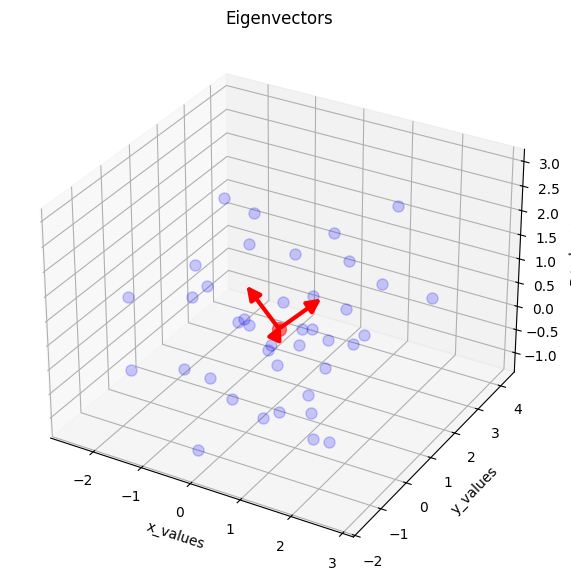

In [23]:
# Required Libraries
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.patches import FancyArrowPatch

# Set random seed
np.random.seed(23)

# Generate class 1 (target = 1)
mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.identity(3)
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)
df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

# Generate class 2 (target = 0)
mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.identity(3)
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)
df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

# Combine both classes
df = pd.concat([df, df1], ignore_index=True)
df = df.sample(40).reset_index(drop=True)

# Perform PCA
pca = PCA(n_components=3)
pca.fit(df[['feature1', 'feature2', 'feature3']])
eigen_vectors = pca.components_

# Custom 3D Arrow class (Fixed for latest matplotlib)
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs
        self._axes = None  # will be set when added to the axes

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        if self._axes is None:
            self._axes = self.axes  # cache the axes on first draw
        xs, ys, _ = proj3d.proj_transform(xs3d, ys3d, zs3d, self._axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        if self._axes is None:
            self._axes = self.axes
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self._axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)  # used for depth ordering


# Plotting
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.plot(df['feature1'], df['feature2'], df['feature3'],
        'o', markersize=8, color='blue', alpha=0.2)

# Mean point of the data
mean_vals = [df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean()]
ax.plot([mean_vals[0]], [mean_vals[1]], [mean_vals[2]],
        'o', markersize=10, color='red', alpha=0.5)

# Plot eigenvectors as arrows
for v in eigen_vectors:
    arrow = Arrow3D([mean_vals[0], mean_vals[0] + v[0]],
                    [mean_vals[1], mean_vals[1] + v[1]],
                    [mean_vals[2], mean_vals[2] + v[2]],
                    mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(arrow)

# Labels and title
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('Eigenvectors')

# Show plot
plt.show()


In [24]:


pc = eigen_vectors[0:2]
pc


array([[ 0.61002583,  0.53982115,  0.58005311],
       [-0.69239396,  0.00718615,  0.72148387]])

In [25]:

transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()


,PC1,PC2,target
0,-1.605154,-0.707594,1
1,0.496582,0.758014,0
2,0.437420,-0.339738,1
3,0.510990,-1.857058,1
4,-1.097907,2.173715,1


In [26]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()